In [529]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import math
from UnifiedMomentumModel.Momentum import UnifiedMomentum, ThrustBasedUnified
from matplotlib.colors import ListedColormap
from scipy.stats import describe
from scipy.interpolate import interp1d
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.lines as mlines

def calc_an(df, ud_key, uinf_key):
    return 1 - (df[ud_key] / df[uinf_key])

def calc_ct(df, ud_key, uinf_key):
    return np.sign(df[ud_key]) * df["Local Thrust Coefficient"] * ((df[ud_key])**2 / (df[uinf_key])**2)

def calc_ctp(df, ud_key, uinf_key):
    return (df["ct_Turb"]) / ((df[ud_key])**2 / (df[uinf_key])**2)

def calc_cp(df, uinf_key = "UInf_Turb"):  # power in PadeOps and UMM is calculated in the turbine frame of reference!
    return df.Power / (0.5 * rho * math.pi * (D/2)**2 * (df[uinf_key])**3)

def round_phases(phase):
    bin_width = 0.05
    n_bins = int(1 / bin_width)
    phase_idx = np.round(phase / bin_width).astype(int)
    phase_idx = np.clip(phase_idx, 0, n_bins)
    phase_bin = phase_idx * bin_width
    return phase_bin


rho, uinf, D, dt = 1, 1, 1, 0.05
Ap_vals = [4, 8, 12, 16]
As_vals = [0.2, 0.4, 0.6, 0.8]
f_vals = [0.2, 0.4, 0.6, 0.8, 1.0]
ct_vals = [1.33, 1.66, 2.00, 2.33]

# get UMM values
def get_tilt_vals(Ap, f, dt):
    T = 1 / f
    omega = 2 * np.pi * f
    phi = np.array([Ap * np.sin(omega * t) for t in np.arange(0, 2*T, dt)])
    phases = np.linspace(0, 1, num = int(len(phi) / 2))
    return np.deg2rad(phi), [phases[i % len(phases)] for i in range(len(phi))]

def get_uturb_vals(As, f, dt):
    T = 1 / f
    omega = 2 * np.pi * f
    uturb = np.array([As * np.cos(omega * t) for t in np.arange(0, 2*T, dt)])
    dx = np.array([(As / omega) * np.sin(omega * t) for t in np.arange(0, 2*T, dt)])
    phases = np.linspace(0, 1, num = int(len(uturb) / 2))
    return uturb, dx, [phases[i % len(phases)] for i in range(len(uturb))]

In [530]:
model = UnifiedMomentum()
col_names = ["Local Thrust Coefficient", "Amplitude", "Distance", "Tilt", "Frequency", "UTurb", "an_Turb", "Ct_Turb", "Cp_Turb", "Phase"]
# get pitch values
pitch_umm_vals = []
for ct in ct_vals:
    for a in Ap_vals:
        for f in f_vals:
            tilts, phases = get_tilt_vals(a, f, dt)
            for (i, tilt) in enumerate(tilts):
                phase = phases[i]
                tilted_vals = model(ct, yaw = 0.0, tilt = tilt)
                vals = (ct, a, np.zeros_like(a), tilt, f, np.zeros_like(a), tilted_vals.an, tilted_vals.Ct, tilted_vals.Cp, phase)
                pitch_umm_vals.append(vals)
                
pitch_umm_vals = np.array(pitch_umm_vals)
df_umm_pitch = pd.DataFrame(pitch_umm_vals, columns = col_names)

/Users/sky/Library/Caches/pypoetry/virtualenvs/simspadeops-Wg-7Zt3Y-py3.11/lib/python3.11/site-packages/UnifiedMomentumModel/Utilities/Geometry.py:89: RuntimeWarning: invalid value encountered in divide
  cos_a = np.divide(np.sin(yaw), sin_eff, where = tilt != 0, out = cos_a)
/Users/sky/Library/Caches/pypoetry/virtualenvs/simspadeops-Wg-7Zt3Y-py3.11/lib/python3.11/site-packages/UnifiedMomentumModel/Utilities/Geometry.py:90: RuntimeWarning: divide by zero encountered in divide
  sin_a = np.divide(-(np.sin(tilt) * np.cos(yaw)), sin_eff, where = tilt != 0, out = sin_a)
/Users/sky/Library/Caches/pypoetry/virtualenvs/simspadeops-Wg-7Zt3Y-py3.11/lib/python3.11/site-packages/UnifiedMomentumModel/Utilities/Geometry.py:94: RuntimeWarning: invalid value encountered in multiply
  w = sin_a * eff_v


In [531]:
# get surge amplitude
surge_umm_vals = []
for ct in ct_vals:
    umm_stationary = model(ct, yaw = 0.0, tilt = 0.0)
    umm_an_stationary = umm_stationary.an
    umm_Cp_stationary = umm_stationary.Cp
    umm_Ct_stationary = umm_stationary.Ct
    for a in As_vals:
        a = np.round(a, decimals = 1)
        for f in f_vals:
            uturb, dx, phases = get_uturb_vals(a, f, dt)
            for (i, ut) in enumerate(uturb):
                x = dx[i]
                phase = phases[i]
                uinf_t = 1 - ut
                Cp = umm_Cp_stationary * (uinf_t**3)
                Ct = umm_Ct_stationary * (uinf_t**2)
                surge_umm_vals.append((ct, a, a / (2 * np.pi * f), 0, f, ut, umm_an_stationary, Ct, Cp, phase))
surge_umm_vals = np.array(surge_umm_vals)
df_umm_surge = pd.DataFrame(surge_umm_vals, columns = col_names)

In [532]:
# create combined pitch + surge dataframe
df_umm_surge["Movement"] = "Surge"
df_umm_pitch["Movement"] = "Pitch"
df_umm = pd.concat([df_umm_surge, df_umm_pitch], ignore_index=True)
df_umm["UInf_Turb"] = (uinf - df_umm["UTurb"]) * np.cos(df_umm["Tilt"])
df_umm["UDisk_Turb"] = (1 - df_umm["an_Turb"]) * df_umm["UInf_Turb"]
df_umm["UDisk_Ground"] = df_umm["UDisk_Turb"] + df_umm["UTurb"]
df_umm["Phase_Rounded"] = round_phases(df_umm["Phase"])

In [533]:
df_umm

,Local Thrust Coefficient,Amplitude,Distance,Tilt,Frequency,UTurb,an_Turb,Ct_Turb,Cp_Turb,Phase,Movement,UInf_Turb,UDisk_Turb,UDisk_Ground,Phase_Rounded
0,1.33,0.2,0.159155,0.000000,0.2,0.200000,0.249143,0.479895,0.288266,0.000000,Surge,0.800000,0.600686,0.800686,0.00
1,1.33,0.2,0.159155,0.000000,0.2,0.199605,0.249143,0.480369,0.288693,0.010101,Surge,0.800395,0.600982,0.800588,0.00
2,1.33,0.2,0.159155,0.000000,0.2,0.198423,0.249143,0.481789,0.289975,0.020202,Surge,0.801577,0.601870,0.800293,0.00
3,1.33,0.2,0.159155,0.000000,0.2,0.196457,0.249143,0.484155,0.292113,0.030303,Surge,0.803543,0.603346,0.799803,0.05
4,1.33,0.2,0.159155,0.000000,0.2,0.193717,0.249143,0.487463,0.295112,0.040404,Surge,0.806283,0.605404,0.799120,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14619,2.33,16.0,0.000000,-0.279253,1.0,0.000000,0.349037,0.912329,0.570886,0.789474,Pitch,0.961262,0.625746,0.625746,0.80
14620,2.33,16.0,0.000000,-0.265585,1.0,0.000000,0.350551,0.915052,0.573444,0.842105,Pitch,0.964939,0.626679,0.626679,0.85
14621,2.33,16.0,0.000000,-0.225920,1.0,0.000000,0.354507,0.922108,0.580089,0.894737,Pitch,0.974588,0.629090,0.629090,0.90
14622,2.33,16.0,0.000000,-0.164141,1.0,0.000000,0.359381,0.930684,0.588201,0.947368,Pitch,0.986559,0.632009,0.632009,0.95


In [534]:
# read in LES data, remove "bad" data, and rename key columns
df_les = pd.read_csv("/Users/sky/src/HowlandLab/data/sim_16_all_runs_data_points_01_26.csv")
df_les = df_les.dropna()
df_les = df_les[df_les["Frequency"] >= 0.2]
df_les = df_les[(((df_les["Movement"] == "Pitch") & (df_les["Amplitude"] < 20)) | ((df_les["Movement"] == "Surge") & (df_les["Amplitude"] < 1)))]
df_les["Model"] = "LES"
df_les = df_les.rename(columns={'UDisk': 'UDisk_Turb', 'Thrust Coefficient': 'Local Thrust Coefficient'}) # disk velocity in the turbine frame of reference

# calculate needed LES quantities per datapoint/timestep
df_les["UDisk_Ground"] = df_les["UDisk_Turb"] + df_les["UTurb"] # disk velocity in the ground frame of reference
df_les["UInf_Turb"] = (uinf - df_les["UTurb"]) * np.cos(df_les["Tilt"])
df_les["UInf_Ground"] = uinf * np.cos(df_les["Tilt"])

df_les["an_Turb"] = calc_an(df_les, ud_key = "UDisk_Turb", uinf_key = "UInf_Turb")
df_les["Ct_Turb"] = calc_ct(df_les, ud_key = "UDisk_Turb", uinf_key = "UInf_Ground")
df_les["Cp_Turb"] = calc_cp(df_les, uinf_key = "UInf_Ground")

In [535]:
df_les["Phase"] = (df_les["Time"] * df_les["Frequency"]) % 1.0
df_les["Phase_Rounded"] = round_phases(df_les["Phase"])

In [536]:
df_les

,Unnamed: 0,Movement,Frequency,Amplitude,Local Thrust Coefficient,Tilt,UTurb,DeltaX,Time,TIDX,...,UDisk_Turb,Model,UDisk_Ground,UInf_Turb,UInf_Ground,an_Turb,Ct_Turb,Cp_Turb,Phase,Phase_Rounded
0,0,Surge,0.2,0.2,1.33,0.000000e+00,0.198423,0.019947,100.05,2001.0,...,0.589355,LES,0.787778,0.801577,1.000000,0.264756,0.461961,0.272259,1.000000e-02,0.00
1,1,Surge,0.2,0.2,1.33,0.000000e+00,0.196457,0.029823,100.10,2002.0,...,0.591869,LES,0.788326,0.803543,1.000000,0.263426,0.465910,0.275758,2.000000e-02,0.00
2,2,Surge,0.2,0.2,1.33,0.000000e+00,0.193717,0.039580,100.15,2003.0,...,0.595028,LES,0.788745,0.806283,1.000000,0.262011,0.470898,0.280198,3.000000e-02,0.05
3,3,Surge,0.2,0.2,1.33,0.000000e+00,0.190211,0.049182,100.20,2004.0,...,0.598821,LES,0.789032,0.809789,1.000000,0.260522,0.476920,0.285590,4.000000e-02,0.05
4,4,Surge,0.2,0.2,1.33,0.000000e+00,0.185955,0.058589,100.25,2005.0,...,0.603229,LES,0.789185,0.814045,1.000000,0.258973,0.483968,0.291944,5.000000e-02,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783995,783995,Pitch,1.0,16.0,2.33,-2.259202e-01,0.000000,0.000000,299.80,5996.0,...,0.626641,LES,0.626641,0.974588,0.974588,0.357020,0.963276,0.619367,8.000000e-01,0.80
783996,783996,Pitch,1.0,16.0,2.33,-1.641406e-01,0.000000,0.000000,299.85,5997.0,...,0.639451,LES,0.639451,0.986559,0.986559,0.351838,0.978867,0.634465,8.500000e-01,0.85
783997,783997,Pitch,1.0,16.0,2.33,-8.629382e-02,0.000000,0.000000,299.90,5998.0,...,0.649721,LES,0.649721,0.996279,0.996279,0.347853,0.990940,0.646239,9.000000e-01,0.90
783998,783998,Pitch,1.0,16.0,2.33,5.952958e-11,0.000000,0.000000,299.95,5999.0,...,0.653379,LES,0.653379,1.000000,1.000000,0.346621,0.994687,0.649907,9.500000e-01,0.95


In [576]:
def first_max_phase_smooth(
    df,
    var_col="Ct_Turb",
):
    results = []

    grouped = df.groupby(["Local Thrust Coefficient", "Frequency", "Amplitude",  "Movement"])
    
    for (ltc, freq, amp, move), group in grouped:
        group = group.sort_values("Phase")
        phases = group["Phase"].values
        values = group[var_col].values

        if len(values) == 0:
            continue

        # find index of max Ct_Turb
        idx_max = np.argmax(values)

        # get the phase at that index
        phase_max = phases[idx_max]

        results.append({
            "Local Thrust Coefficient": ltc,
            "Frequency": freq,
            "Amplitude": amp,
            "Movement": move,
            "Phase_Diff": phase_max - 0.5,
        })

    return pd.DataFrame(results)


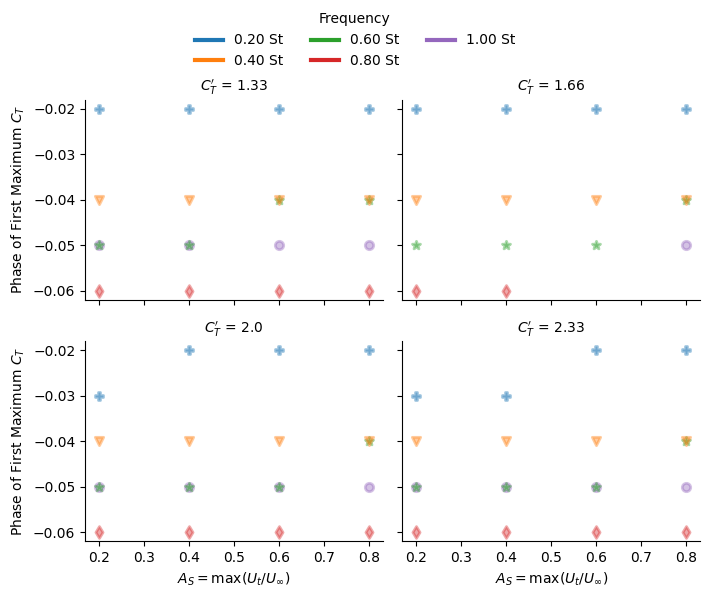

In [581]:
phase_max_les_vals = first_max_phase_smooth(df_les[df_les["Movement"] == "Surge"])

g = sns.FacetGrid(
    phase_max_les_vals,
    col="Local Thrust Coefficient",
    margin_titles=True,
    sharex=True,
    sharey=True,
    height=3,
    aspect=1.2,
    col_wrap=2
)

# Global frequency ordering
freqs_all = np.sort(phase_max_les_vals["Frequency"].unique())
freqs_plot = freqs_all[::-1]   # largest plotted first

# Consistent colors across facets
colors = sns.color_palette("tab10", len(freqs_all))
color_map = dict(zip(freqs_all, colors))

marker_map = dict(zip(freqs_all, ["P", "v", "*", "d", "o"]))

for ltc, ax in g.axes_dict.items():
    df_ltc = phase_max_les_vals[phase_max_les_vals["Local Thrust Coefficient"] == ltc]

    for freq in freqs_plot:
        df_sub = (
            df_ltc[df_ltc["Frequency"] == freq]
            .sort_values("Amplitude")
        )

        if df_sub.empty:
            continue

        # Fade higher frequencies
        alpha = 0.15 + 0.5 * (freq == freqs_all.min())

        ax.scatter(
            df_sub["Amplitude"],
            df_sub["Phase_Diff"],
            color=color_map[freq],
            marker=marker_map[freq],
            linewidth=2,
            label=f"{freq:.2f} St",
            alpha = 0.4
        )


# Axis + titles
g.set_axis_labels(
    "$A_S = \max{(U_{t} / U_\infty)}$",
    "Phase of First Maximum $C_T$"
)
g.set_titles(col_template=r"$C_T'$ = {col_name}")

# --- Create custom legend ---
# 1. Color handles for frequency
color_handles = [
    mlines.Line2D([], [], color=color_map[f], linestyle='solid', linewidth=3)
    for f in freqs_plot[::-1]  # show smallest first
]
color_labels = [f"{f:.2f} St" for f in freqs_plot[::-1]]


# Place both legends
g.fig.legend(
    color_handles,
    color_labels,
    title="Frequency",
    loc="upper center",
    ncol=3,
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.9])


In [537]:
# group LES and UMM by movement, frequency, amplitude, and rounded phase
group_keys = ["Local Thrust Coefficient", "Frequency", "Amplitude", "Movement", "Phase_Rounded"]
value_keys = ["an_Turb", "Ct_Turb", "Cp_Turb"]
df_umm_avg = df_umm.groupby(group_keys)[value_keys].mean().reset_index()
df_les_avg = df_les.groupby(group_keys)[value_keys].mean().reset_index()

# Select only the columns we need for comparison
cols_to_merge = group_keys + value_keys
df_umm_sub = df_umm_avg[cols_to_merge]
df_les_sub = df_les_avg[cols_to_merge]

In [538]:
def check_movement_values_grid(df, y_key = "Ct_Turb"):
    g = sns.FacetGrid(
        df,
        row="Frequency",
        col="Local Thrust Coefficient",
        hue="Amplitude",
        margin_titles=True,
        sharex=True,
        sharey=True,
        height=3,
        aspect=1.2
    )

    g.map_dataframe(
        sns.lineplot,
        x="Phase_Rounded",
        y=y_key,
        marker="o"
    )

    g.add_legend(title="Amplitude")

    g.set_axis_labels("Phase", y_key)
    g.set_titles(col_template=r"$C_T'$ = {col_name}",
                row_template="f = {row_name} Hz")

In [539]:
def check_movement_values_grid_dual(
    df_les,
    df_umm,
    y_key="Ct_Turb"
):
    # Get unique facet values
    freqs = sorted(df_les["Frequency"].unique())
    ltcs = sorted(df_les["Local Thrust Coefficient"].unique())
    amps = sorted(df_les["Amplitude"].unique())

    # Create FacetGrid by row=Frequency, col=LTC, hue=Amplitude
    g = sns.FacetGrid(
        df_les,
        row="Frequency",
        col="Local Thrust Coefficient",
        hue="Amplitude",
        margin_titles=True,
        sharex=True,
        sharey=True,
        height=3,
        aspect=1.2
    )

    # Consistent color map by amplitude
    palette = sns.color_palette("tab10", n_colors=len(amps))
    color_map = dict(zip(amps, palette))

    # Define markers / line styles for LES vs UMM
    dataset_styles = {
        "LES": {"linestyle": "-", "marker": "o"},
        "UMM": {"linestyle": "--", "marker": "s"}
    }

    # Loop over all facets
    for (freq, ltc), ax in g.axes_dict.items():
        # LES subset
        df_les_sub = df_les[
            (df_les["Frequency"] == freq) &
            (df_les["Local Thrust Coefficient"] == ltc)
        ].sort_values("Phase_Rounded")

        # UMM subset
        df_umm_sub = df_umm[
            (df_umm["Frequency"] == freq) &
            (df_umm["Local Thrust Coefficient"] == ltc)
        ].sort_values("Phase_Rounded")

        # Plot each amplitude separately
        for amp in amps:
            # LES
            df_amp_les = df_les_sub[df_les_sub["Amplitude"] == amp]
            if not df_amp_les.empty:
                ax.plot(
                    df_amp_les["Phase_Rounded"],
                    df_amp_les[y_key],
                    color=color_map[amp],
                    linestyle=dataset_styles["LES"]["linestyle"],
                    marker=dataset_styles["LES"]["marker"],
                    label=f"LES, A={amp}",
                    alpha = 0.7
                )

            # UMM
            df_amp_umm = df_umm_sub[df_umm_sub["Amplitude"] == amp]
            if not df_amp_umm.empty:
                ax.plot(
                    df_amp_umm["Phase_Rounded"],
                    df_amp_umm[y_key],
                    color=color_map[amp],
                    linestyle=dataset_styles["UMM"]["linestyle"],
                    marker=dataset_styles["UMM"]["marker"],
                    label=f"UMM, A={amp}",
                    alpha = 0.7
                )

    # Axis labels and titles
    g.set_axis_labels("Phase", y_key)
    g.set_titles(
        col_template=r"$C_T'$ = {col_name}",
        row_template="f = {row_name} Hz"
    )

    # Create a single legend combining both datasets
    handles, labels = [], []
    for ax in g.axes.flat:
        h, l = ax.get_legend_handles_labels()
        handles += h
        labels += l

    # Remove duplicates
    from collections import OrderedDict
    by_label = OrderedDict(zip(labels, handles))
    g.fig.legend(
        by_label.values(),
        by_label.keys(),
        title="Dataset / Amplitude",
        loc="upper center",
        ncol=4,
        frameon=False
    )

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()


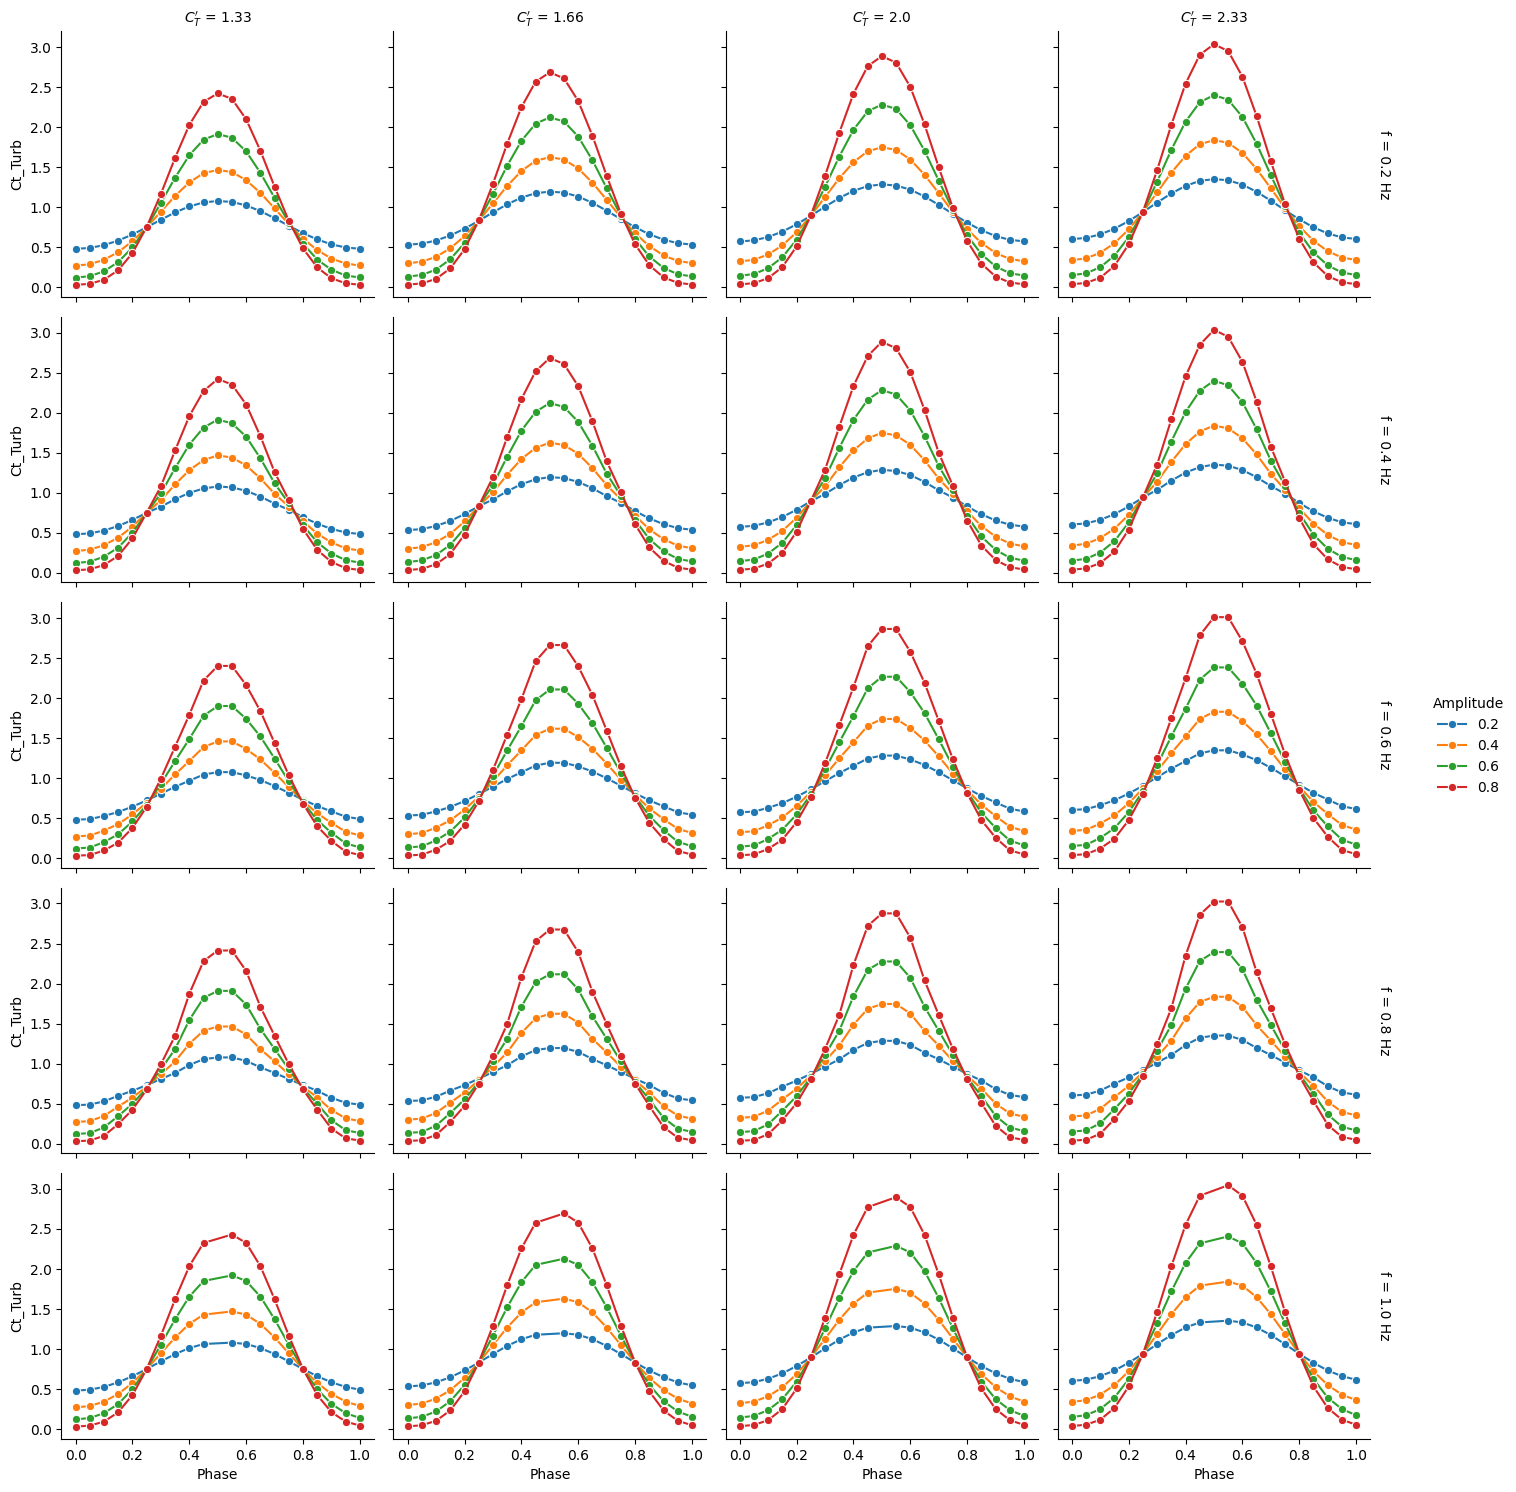

In [540]:
df_umm_surge = df_umm_sub[df_umm_sub["Movement"] == "Surge"]
check_movement_values_grid(df_umm_surge, y_key = "Ct_Turb")

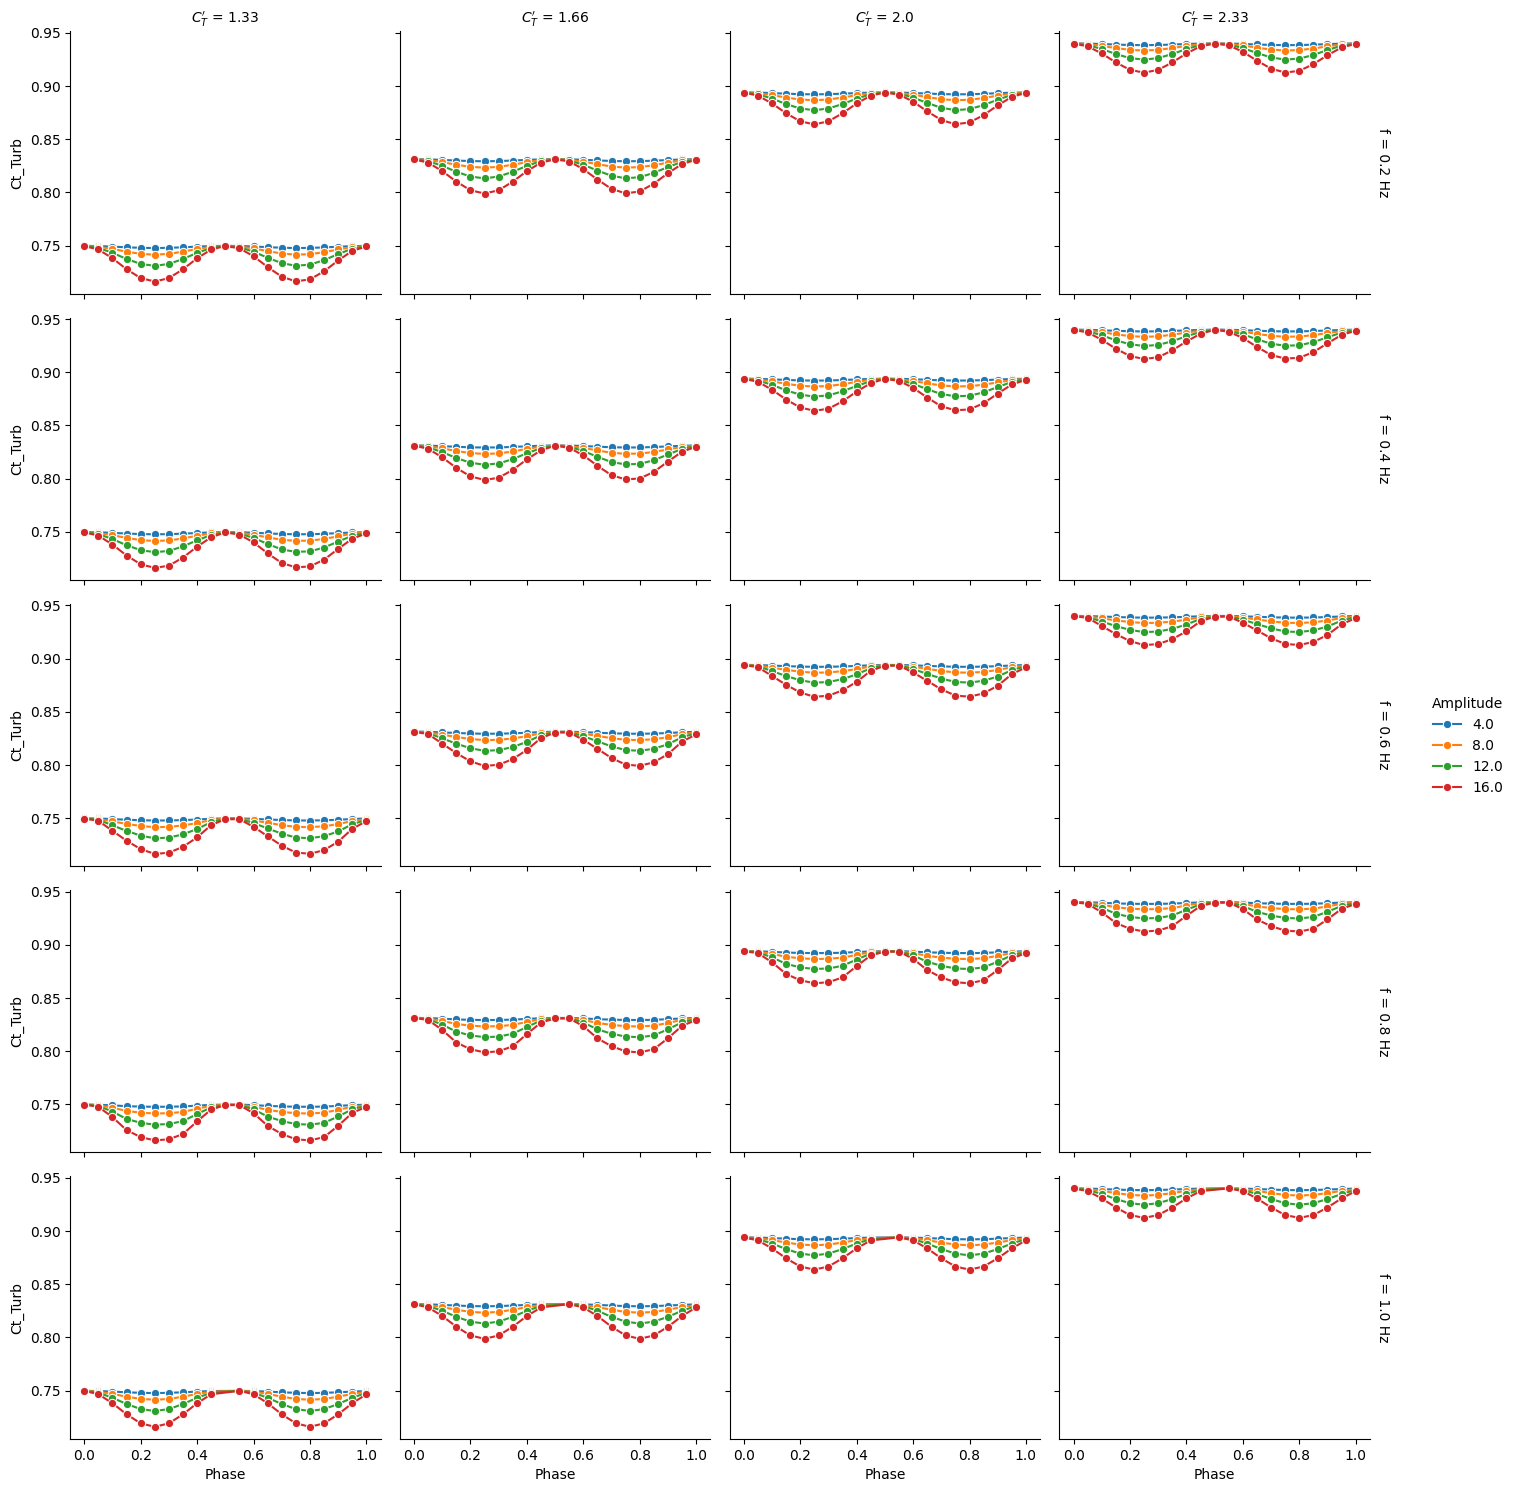

In [541]:
df_umm_pitch = df_umm_sub[df_umm_sub["Movement"] == "Pitch"]
check_movement_values_grid(df_umm_pitch, y_key = "Ct_Turb")

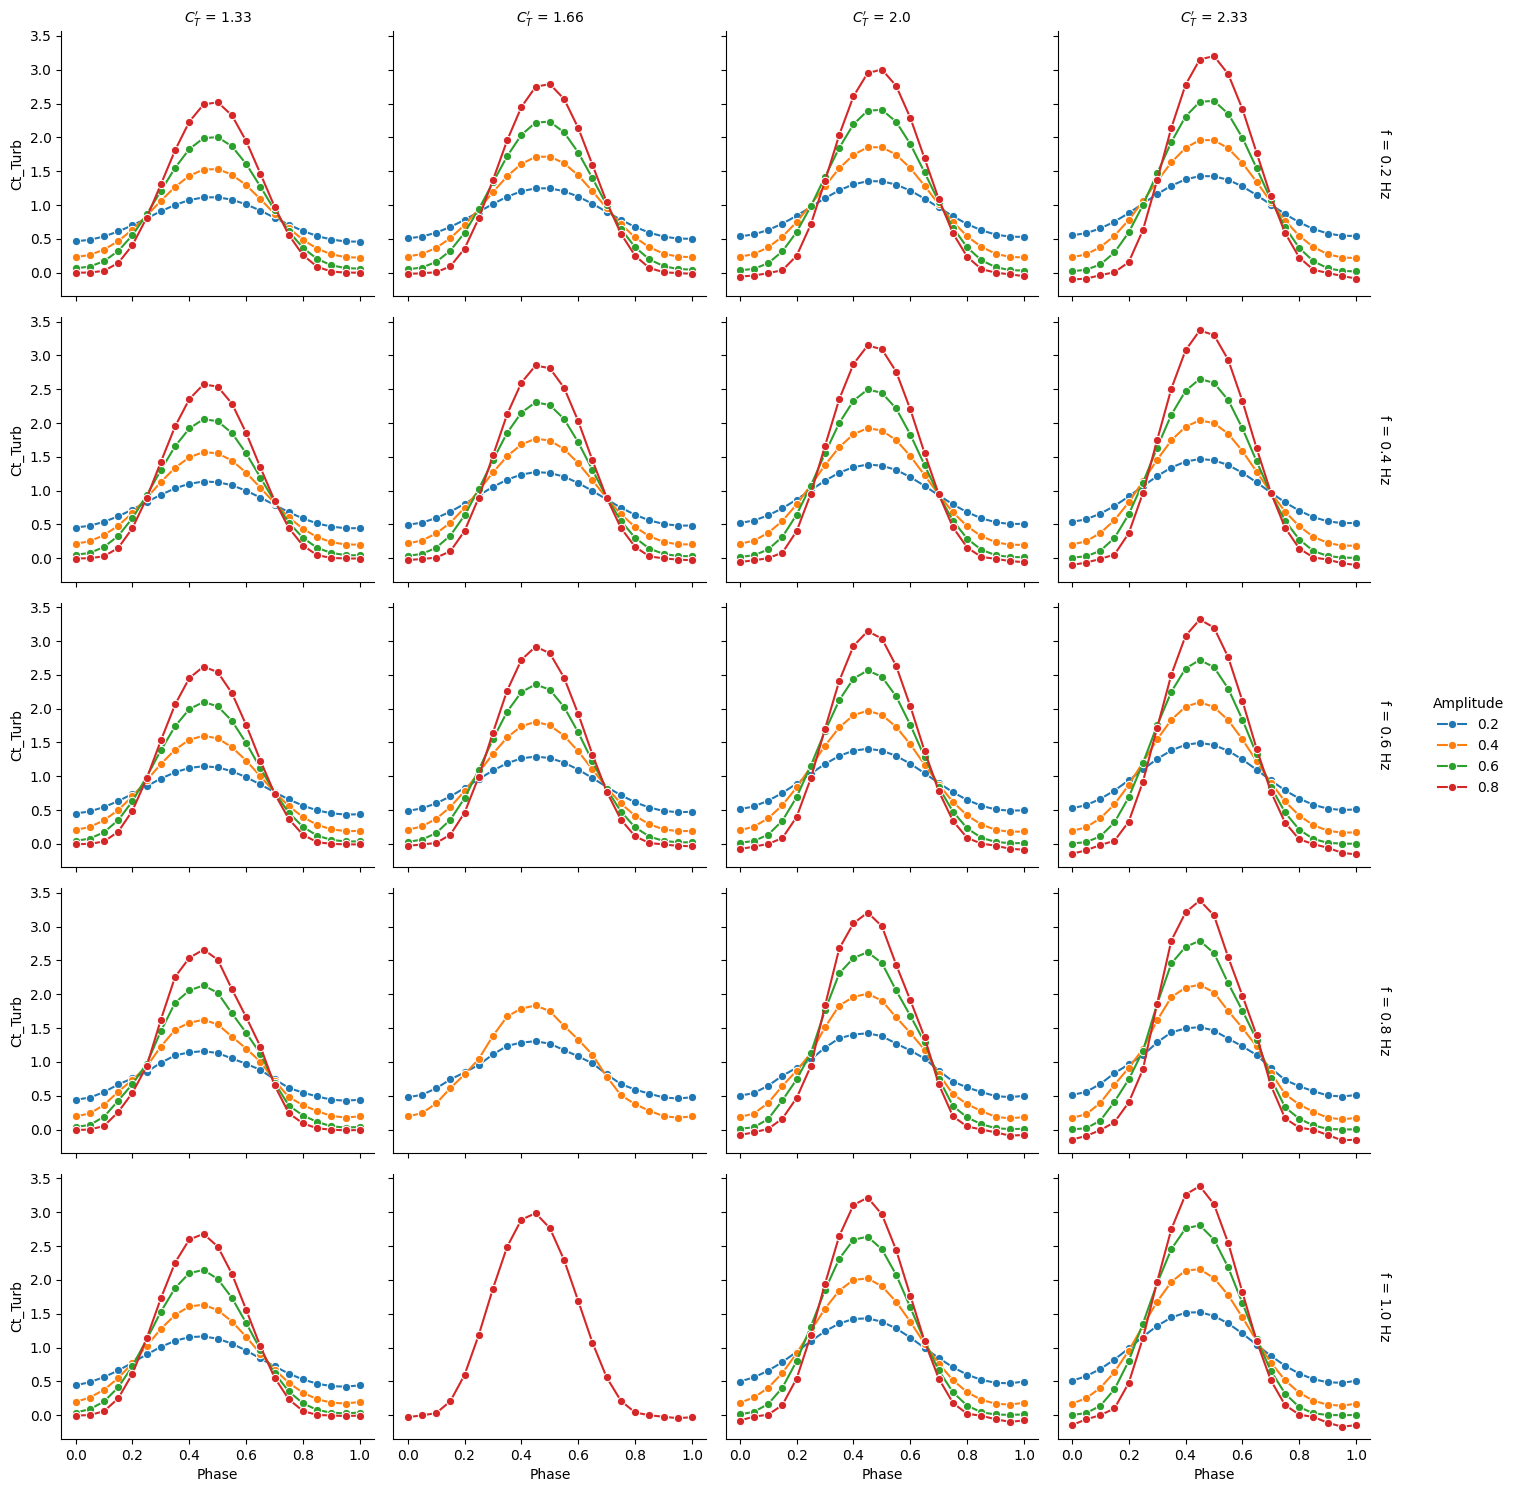

In [542]:
df_les_surge = df_les_sub[df_les_sub["Movement"] == "Surge"]
check_movement_values_grid(df_les_surge, y_key = "Ct_Turb")

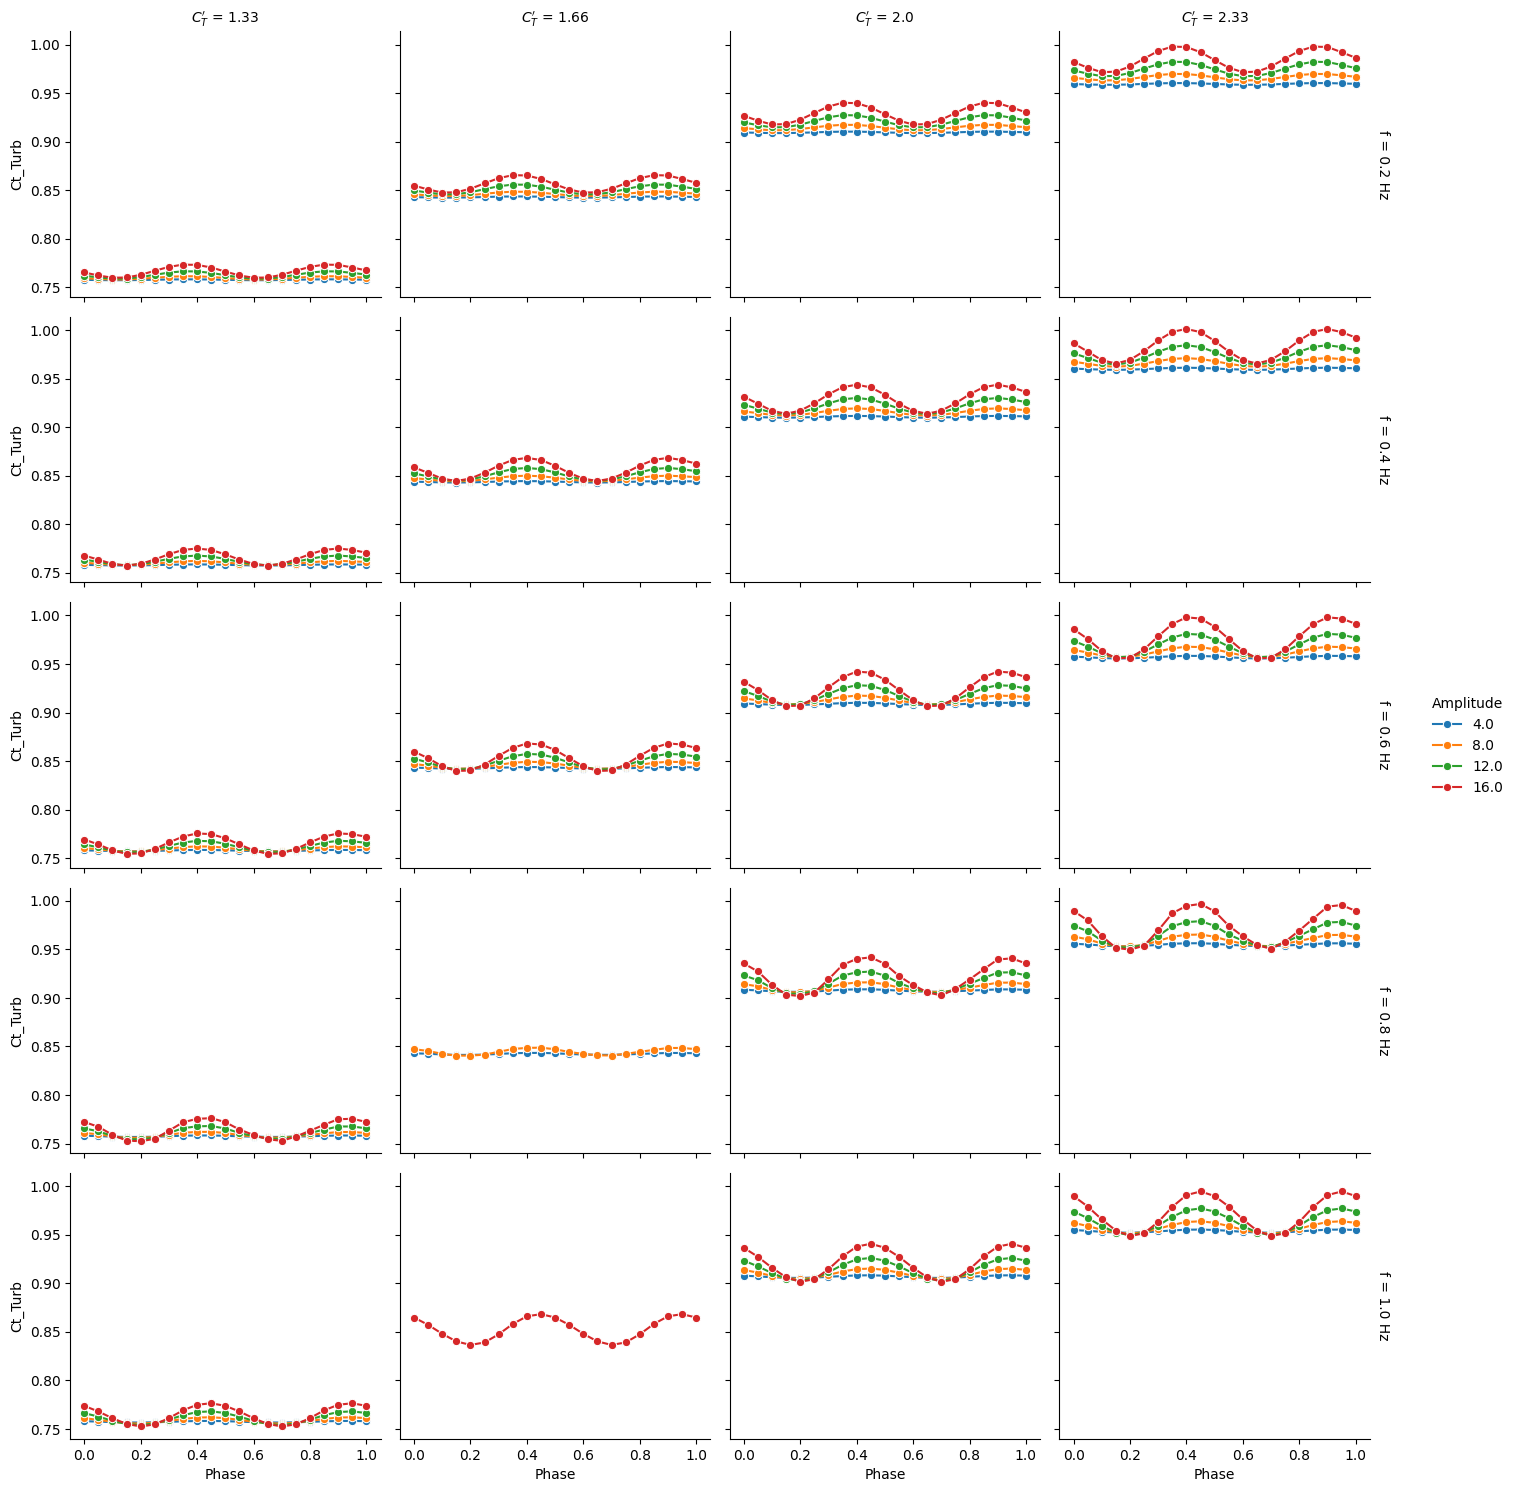

In [543]:
df_les_pitch = df_les_sub[df_les_sub["Movement"] == "Pitch"]
check_movement_values_grid(df_les_pitch, y_key = "Ct_Turb")

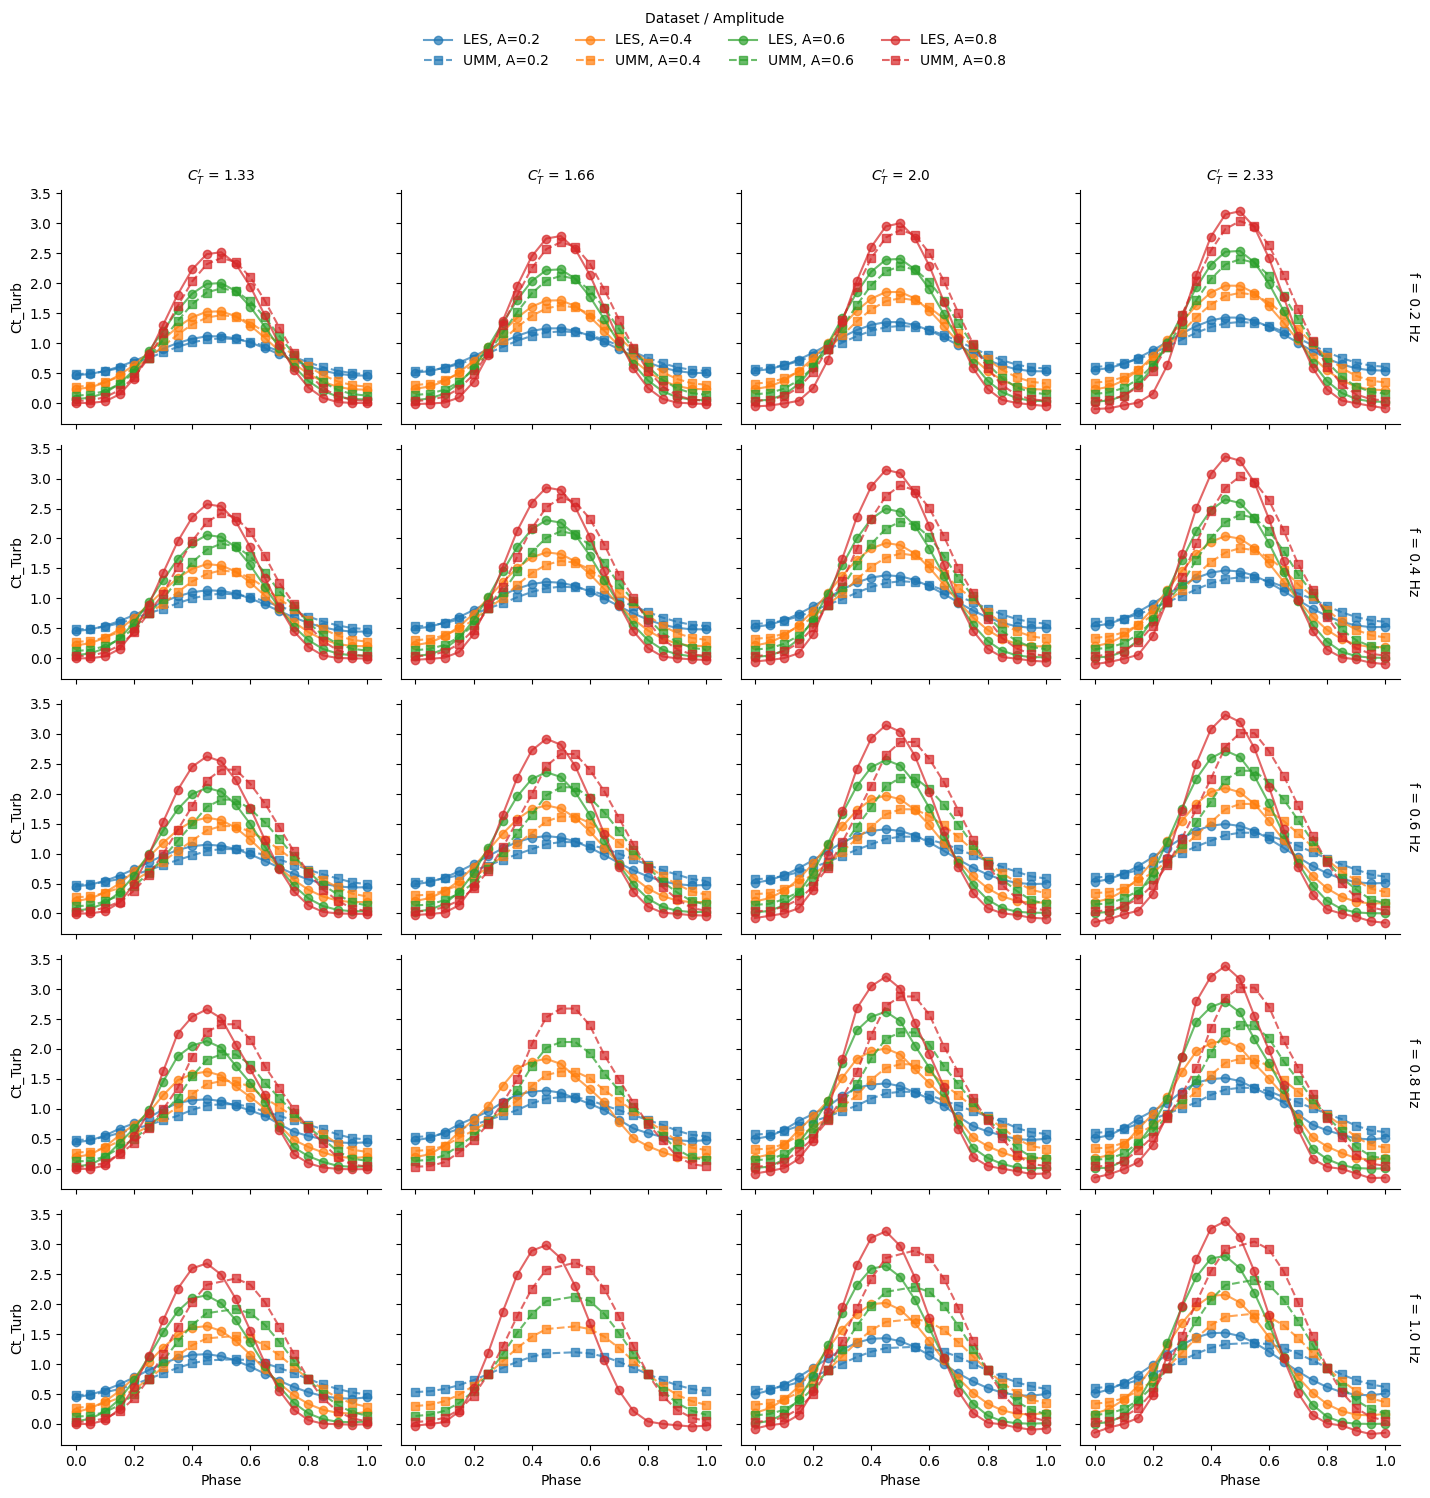

In [544]:
check_movement_values_grid_dual(
    df_les_surge,
    df_umm_surge,
    y_key="Ct_Turb")

In [545]:
# Merge on the grouping keys
df_merged = pd.merge(
    df_les_sub,
    df_umm_sub,
    on=group_keys,
    suffixes=("_LES", "_UMM")
)

df_merged["an_diff"] = (df_merged["an_Turb_LES"] - df_merged["an_Turb_UMM"]) 
df_merged["Ct_diff"] = (df_merged["Ct_Turb_LES"] - df_merged["Ct_Turb_UMM"])
df_merged["Cp_diff"] = (df_merged["Cp_Turb_LES"] - df_merged["Cp_Turb_UMM"])

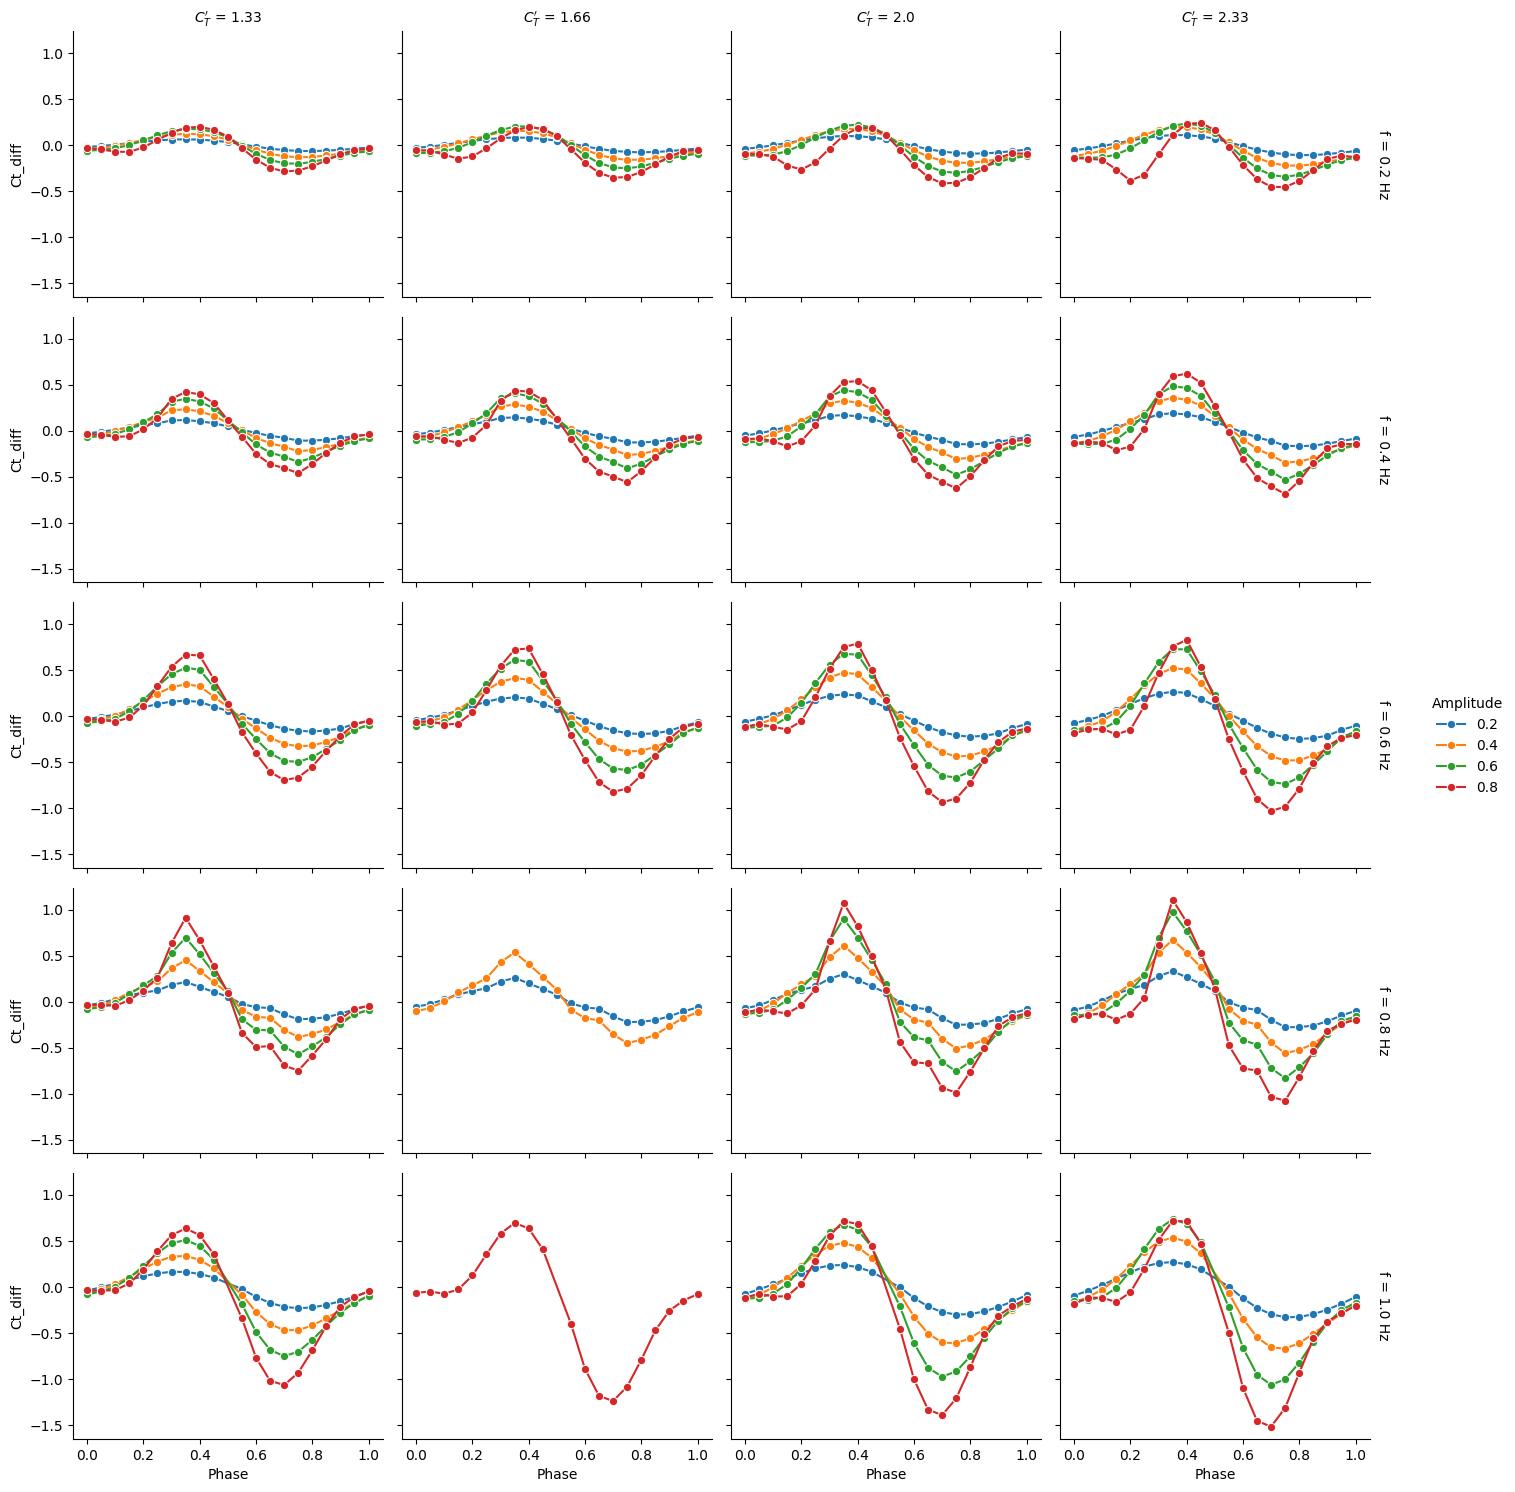

In [546]:
df_merge_surge = df_merged[df_merged["Movement"] == "Surge"]
check_movement_values_grid(df_merge_surge, y_key = "Ct_diff")
# df_merge_pitch = df_merged[df_merged["Movement"] == "Pitch"]
# check_movement_values_grid(df_merge_pitch, y_key = "Ct_diff")

In [570]:
def first_max_phase_smooth(
    df,
    var_col="Ct_Turb",
):
    results = []

    grouped = df.groupby(["Local Thrust Coefficient", "Frequency", "Amplitude",  "Movement"])
    
    for (ltc, freq, amp, move), group in grouped:
        group = group.sort_values("Phase")
        phases = group["Phase"].values
        les_phase_max = 0
        umm_phase_max = 0
        for suffix in ["_LES", "_UMM"]:
            values = group[var_col + suffix].values

            if len(values) == 0:
                continue

            # find index of max Ct_Turb
            idx_max = np.argmax(values)

            # get the phase at that index
            phase_max = phases[idx_max]

            # Rounded phase at this first maximum
            if suffix == "_LES":
                les_phase_max = phase_max
            else:
                umm_phase_max = phase_max
        results.append({
            "Local Thrust Coefficient": ltc,
            "Frequency": freq,
            "Amplitude": amp,
            "Movement": move,
            "Phase_diff": les_phase_max - umm_phase_max,
        })

    return pd.DataFrame(results)


In [571]:
phase_max_vals = first_max_phase_smooth(df_merge_surge)
df = phase_max_vals

g = sns.FacetGrid(
    df,
    col="Local Thrust Coefficient",
    margin_titles=True,
    sharex=True,
    sharey=True,
    height=3,
    aspect=1.2,
    col_wrap=2
)

# Global frequency ordering
freqs_all = np.sort(df["Frequency"].unique())
freqs_plot = freqs_all[::-1]   # largest plotted first

# Consistent colors across facets
colors = sns.color_palette("tab10", len(freqs_all))
color_map = dict(zip(freqs_all, colors))

marker_map = dict(zip(freqs_all, ["o", "v", "*", "d", "P"]))

for ltc, ax in g.axes_dict.items():
    df_ltc = df[df["Local Thrust Coefficient"] == ltc]

    for freq in freqs_plot:
        df_sub = (
            df_ltc[df_ltc["Frequency"] == freq]
            .sort_values("Amplitude")
        )

        if df_sub.empty:
            continue

        # Fade higher frequencies
        alpha = 0.15 + 0.5 * (freq == freqs_all.min())

        ax.scatter(
            df_sub["Amplitude"],
            df_sub["Phase_diff"],
            color=color_map[freq],
            marker=marker_map[freq],
            linewidth=2,
            label=f"{freq:.2f} St",
            alpha = 0.5
        )


# Axis + titles
g.set_axis_labels(
    "$A_S = \max{(U_{t} / U_\infty)}$",
    "Phase of First Maximum $C_T$"
)
g.set_titles(col_template=r"$C_T'$ = {col_name}")

# --- Create custom legend ---
# 1. Color handles for frequency
color_handles = [
    mlines.Line2D([], [], color=color_map[f], linestyle='solid', linewidth=3)
    for f in freqs_plot[::-1]  # show smallest first
]
color_labels = [f"{f:.2f} St" for f in freqs_plot[::-1]]


# Place both legends
g.fig.legend(
    color_handles,
    color_labels,
    title="Frequency",
    loc="upper center",
    ncol=3,
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.9])


KeyError: 'Phase'

In [ ]:
# Aggregate function dictionary
result_keys = ["Local Thrust Coefficient", "Frequency", "Amplitude", "Movement"]
agg_dict = {
    "an_Turb_LES": ["mean", "max", "min"],
    "Ct_Turb_LES": ["mean", "max", "min"],
    "Cp_Turb_LES": ["mean", "max", "min"],
    "an_Turb_UMM": ["mean", "max", "min"],
    "Ct_Turb_UMM": ["mean", "max", "min"],
    "Cp_Turb_UMM": ["mean", "max", "min"],
    "an_diff": ["mean", "max", "min"],
    "Ct_diff": ["mean", "max", "min"],
    "Cp_diff": ["mean", "max", "min"]
}

# Group and aggregate
df_stats = df_merged.groupby(result_keys).agg(agg_dict).reset_index()
df_stats.columns = [
    f"{col[0]}_{col[1]}" if col[1] != "" else col[0]
    for col in df_stats.columns
]

In [ ]:
df_stats["Ct_mean_diff"] = df_stats["Ct_Turb_LES_mean"] - df_stats["Ct_Turb_UMM_mean"]
df_stats["Ct_min_diff"] = df_stats["Ct_Turb_LES_min"] - df_stats["Ct_Turb_UMM_min"]
df_stats["Ct_max_diff"] = df_stats["Ct_Turb_LES_max"] - df_stats["Ct_Turb_UMM_max"]

In [ ]:
df_stats["Ct_diff_mean_norm"] = df_stats["Ct_diff_mean"] / df_stats["Ct_Turb_LES_mean"]
df_stats["Ct_diff_min_norm"] = df_stats["Ct_diff_min"] / df_stats["Ct_Turb_LES_mean"]
df_stats["Ct_diff_max_norm"] = df_stats["Ct_diff_max"] / df_stats["Ct_Turb_LES_mean"]

In [ ]:
df_stats_surge = df_stats[df_stats["Movement"] == "Surge"]

In [ ]:
def diff_grid_shaded(
    df,
    y_mean="Ct_diff_mean_norm",
    y_min="Ct_diff_min_norm",
    y_max="Ct_diff_max_norm"
):
    g = sns.FacetGrid(
        df,
        row="Frequency",
        col="Local Thrust Coefficient",
        hue = "Frequency",
        margin_titles=True,
        sharex=True,
        sharey=True,
        height=3,
        aspect=1.2
    )

    for (freq, ltc), ax in g.axes_dict.items():
        df_sub = df[
            (df["Frequency"] == freq) &
            (df["Local Thrust Coefficient"] == ltc)
        ].sort_values("Amplitude")

        # Mean line
        ax.plot(
            df_sub["Amplitude"],
            df_sub[y_mean],
            marker="o"
        )

        # Min–max shading
        ax.fill_between(
            df_sub["Amplitude"],
            df_sub[y_min],
            df_sub[y_max],
            alpha=0.3
        )

    g.set_axis_labels("Amplitude", y_mean)
    g.set_titles(
        row_template="f = {row_name} Hz",
        col_template=r"$\Delta C_T'$ = {col_name}"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def diff_grid_shaded_freq(
    df,
    y_mean="Ct_diff_mean_norm",
    y_min="Ct_diff_min_norm",
    y_max="Ct_diff_max_norm"
):
    g = sns.FacetGrid(
        df,
        col="Local Thrust Coefficient",
        margin_titles=True,
        sharex=True,
        sharey=True,
        height=3,
        aspect=1.2,
        col_wrap=2
    )

    # Global frequency ordering
    freqs_all = np.sort(df["Frequency"].unique())
    freqs_plot = freqs_all[::-1]   # largest plotted first

    # Consistent colors across facets
    colors = sns.color_palette("tab10", len(freqs_all))
    color_map = dict(zip(freqs_all, colors))

    for ltc, ax in g.axes_dict.items():
        df_ltc = df[df["Local Thrust Coefficient"] == ltc]

        for freq in freqs_plot:
            df_sub = (
                df_ltc[df_ltc["Frequency"] == freq]
                .sort_values("Amplitude")
            )

            if df_sub.empty:
                continue

            # Fade higher frequencies
            alpha = 0.15 + 0.5 * (freq == freqs_all.min())

            ax.plot(
                df_sub["Amplitude"],
                df_sub[y_mean],
                color=color_map[freq],
                linestyle="--",
                linewidth=2,
                label=f"{freq:.2f} St"
            )

            ax.fill_between(
                df_sub["Amplitude"],
                df_sub[y_min],
                df_sub[y_max],
                color=color_map[freq],
                alpha=alpha * 0.7
            )

    # Axis + titles
    g.set_axis_labels("$A_S = \max{(U_{t} / U_\infty)}$", "$\Delta C_T = C_{T_{\\text{LES}}} -  C_{T_{\\text{UMM}}}$")
    g.set_titles(col_template=r"$C_T'$ = {col_name}")

    # Legend ordered from smallest to largest frequency
    handles, labels = ax.get_legend_handles_labels()
    handles_labels = sorted(
        zip(handles, labels),
        key=lambda hl: float(hl[1].split()[0])
    )
    handles, labels = zip(*handles_labels)

    g.fig.legend(
        handles,
        labels,
        title="Frequency",
        loc="upper center",
        ncol=len(labels),
        frameon=False
    )

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()


In [ ]:
def diff_grid_shaded_amp(
    df,
    y_mean="Ct_diff_mean_norm",
    y_min="Ct_diff_min_norm",
    y_max="Ct_diff_max_norm"
):
    g = sns.FacetGrid(
        df,
        col="Local Thrust Coefficient",
        margin_titles=True,
        sharex=True,
        sharey=True,
        height=3,
        aspect=1.2,
        col_wrap=2
    )

    # Global frequency ordering
    amps_all = np.sort(df["Amplitude"].unique())
    amps_plot = amps_all[::-1]   # largest plotted first

    # Consistent colors across facets
    colors = sns.color_palette("tab10", len(amps_all))
    color_map = dict(zip(amps_all, colors))

    for ltc, ax in g.axes_dict.items():
        df_ltc = df[df["Local Thrust Coefficient"] == ltc]

        for amp in amps_plot:
            df_sub = (
                df_ltc[df_ltc["Amplitude"] == amp]
                .sort_values("Amplitude")
            )

            if df_sub.empty:
                continue

            # Fade higher frequencies
            alpha = 0.15 + 0.5 * (amp == amps_all.min())

            ax.plot(
                df_sub["Frequency"],
                df_sub[y_mean],
                color=color_map[amp],
                linestyle="--",
                linewidth=2,
                label=f"{amp:.2f}"
            )

            ax.fill_between(
                df_sub["Frequency"],
                df_sub[y_min],
                df_sub[y_max],
                color=color_map[amp],
                alpha=alpha * 0.7
            )

    # Axis + titles
    g.set_axis_labels("$St$", "$\Delta C_T = C_{T_{\\text{LES}}} -  C_{T_{\\text{UMM}}}$")
    g.set_titles(col_template=r"$C_T'$ = {col_name}")

    # Legend ordered from smallest to largest frequency
    handles, labels = ax.get_legend_handles_labels()
    handles_labels = sorted(
        zip(handles, labels),
        key=lambda hl: float(hl[1].split()[0])
    )
    handles, labels = zip(*handles_labels)

    g.fig.legend(
        handles,
        labels,
        title="$A_S = \max{(U_{t} / U_\infty)}$",
        loc="upper center",
        ncol=len(labels),
        frameon=False
    )

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()


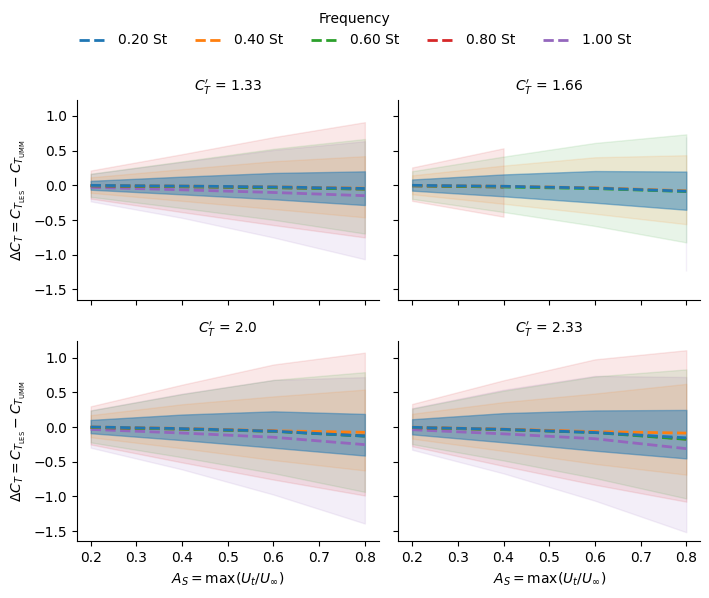

In [ ]:
diff_grid_shaded_freq(df_stats_surge,
    y_mean="Ct_diff_mean",
    y_min="Ct_diff_min",
    y_max="Ct_diff_max"
)

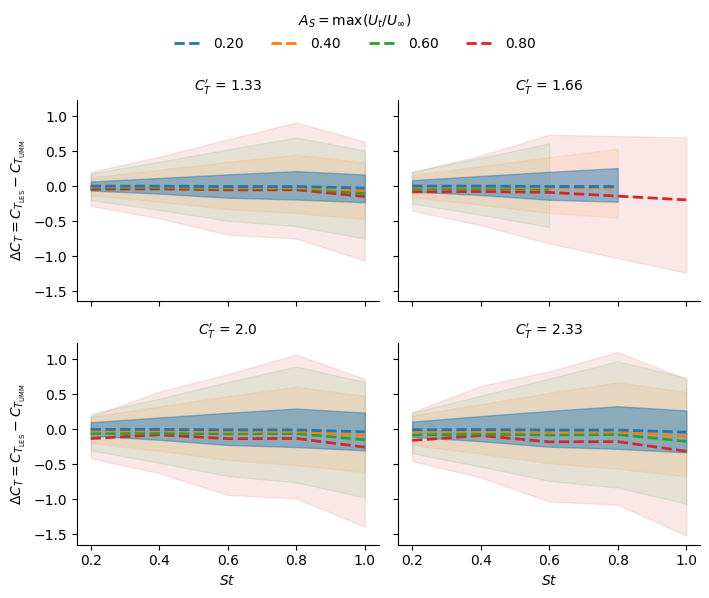

In [ ]:
diff_grid_shaded_amp(df_stats_surge,
    y_mean="Ct_diff_mean",
    y_min="Ct_diff_min",
    y_max="Ct_diff_max"
)

In [ ]:
def diff_grid_mean_min_max(
    df,
    y_mean="Ct_diff_mean_norm",
    y_min="Ct_diff_min_norm",
    y_max="Ct_diff_max_norm"
):
    g = sns.FacetGrid(
        df,
        col="Local Thrust Coefficient",
        margin_titles=True,
        sharex=True,
        sharey=True,
        height=3,
        aspect=1.2,
        col_wrap=2
    )

    # Global frequency ordering
    freqs_all = np.sort(df["Frequency"].unique())
    freqs_plot = freqs_all[::-1]   # largest plotted first

    # Consistent colors across facets
    colors = sns.color_palette("tab10", len(freqs_all))
    color_map = dict(zip(freqs_all, colors))

    for ltc, ax in g.axes_dict.items():
        df_ltc = df[df["Local Thrust Coefficient"] == ltc]

        for freq in freqs_plot:
            df_sub = (
                df_ltc[df_ltc["Frequency"] == freq]
                .sort_values("Amplitude")
            )

            if df_sub.empty:
                continue

            # Fade higher frequencies
            alpha = 0.15 + 0.5 * (freq == freqs_all.min())

            ax.plot(
                df_sub["Amplitude"],
                df_sub[y_mean],
                color=color_map[freq],
                linestyle="solid",
                linewidth=2,
                label=f"{freq:.2f} St"
            )

            ax.plot(
                df_sub["Amplitude"],
                df_sub[y_min],
                color=color_map[freq],
                linestyle="dotted",
                linewidth=2,
                label=f"{freq:.2f} St"
            )

            ax.plot(
                df_sub["Amplitude"],
                df_sub[y_max],
                color=color_map[freq],
                linestyle="dashed",
                linewidth=2,
                label=f"{freq:.2f} St"
            )

 # Axis + titles
    g.set_axis_labels(
        "$A_S = \max{(U_{t} / U_\infty)}$",
        "$\Delta C_T = C_{T_{\\text{LES}}} -  C_{T_{\\text{UMM}}}$"
    )
    g.set_titles(col_template=r"$C_T'$ = {col_name}")

    # --- Create custom legend ---
    # 1. Color handles for frequency
    color_handles = [
        mlines.Line2D([], [], color=color_map[f], linestyle='solid', linewidth=3)
        for f in freqs_plot[::-1]  # show smallest first
    ]
    color_labels = [f"{f:.2f} St" for f in freqs_plot[::-1]]

    # 2. Line style handles for mean/min/max
    style_handles = [
        mlines.Line2D([], [], color="black", linestyle="solid", linewidth=2),
        mlines.Line2D([], [], color="black", linestyle="dashed", linewidth=2),
        mlines.Line2D([], [], color="black", linestyle="dotted", linewidth=2)
    ]
    style_labels = ["Mean", "Max", "Min"]

    # Place both legends
    g.fig.legend(
        color_handles,
        color_labels,
        title="Frequency",
        loc="upper center",
        ncol=3,
        frameon=False
    )

    g.fig.legend(
        style_handles,
        style_labels,
        title="Statistic",
        loc="upper right",
        frameon=False
    )

    plt.tight_layout(rect=[0, 0, 1, 0.9])


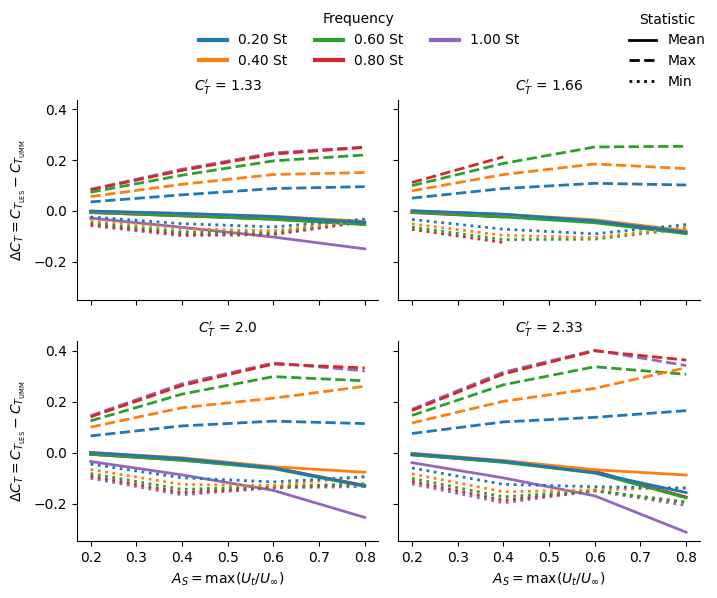

In [ ]:
diff_grid_mean_min_max(df_stats_surge,
    y_mean="Ct_mean_diff",
    y_min="Ct_min_diff",
    y_max="Ct_max_diff"
)